<a href="https://colab.research.google.com/github/Arkrishx/python-data-analytics-/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT: Food delivery insights

In [1]:
from google.colab import files

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

uploaded = files.upload()

df = pd.read_csv('food_delivery_data.csv')

print(df)



Saving food_delivery_data.csv to food_delivery_data.csv
    Order_ID Customer_ID  Order_Date Order_Time Day_of_Week      Location  \
0    ORD0001     CUST024  23-05-2025      12:47      Friday     Velachery   
1    ORD0002     CUST196  02-12-2024      13:48      Monday      Tambaram   
2    ORD0003     CUST076  28-03-2025      19:34      Friday   Kodambakkam   
3    ORD0004     CUST042  29-01-2025      09:55   Wednesday      Tambaram   
4    ORD0005     CUST164  16-04-2025      19:46   Wednesday  Nungambakkam   
..       ...         ...         ...        ...         ...           ...   
495  ORD0496     CUST128  15-04-2025      13:27     Tuesday         Porur   
496  ORD0497     CUST169  12-01-2025      20:20      Sunday      Mylapore   
497  ORD0498     CUST092  22-03-2025      13:07    Saturday  Nungambakkam   
498  ORD0499     CUST145  22-01-2025      12:55   Wednesday   Kodambakkam   
499  ORD0500     CUST175  02-02-2025      19:49      Sunday      T. Nagar   

                Foo

In [25]:
df.head()

,Order_ID,Customer_ID,Order_Date,Order_Time,Day_of_Week,Location,Food_Item,Category,Quantity,Unit_Price,Total_Amount,Delivery_Fee,Grand_Total,Payment_Method,Delivery_Time_Min,Customer_Rating
0,ORD0001,CUST024,23-05-2025,12:47,Friday,Velachery,Fried Rice,Rice Dishes,1,128,128,20,148,UPI,25.0,2.60
1,ORD0002,CUST196,02-12-2024,13:48,Monday,Tambaram,Pizza,Fast Food,2,262,524,40,564,Cash,47.0,2.90
2,ORD0003,CUST076,28-03-2025,19:34,Friday,Kodambakkam,Dosa,South Indian,1,61,61,30,91,Credit Card,44.0,3.72
3,ORD0004,CUST042,29-01-2025,09:55,Wednesday,Tambaram,Chicken Curry,Curry,1,161,161,20,181,Credit Card,37.0,4.60
4,ORD0005,CUST164,16-04-2025,19:46,Wednesday,Nungambakkam,Fried Rice,Rice Dishes,2,141,282,0,282,UPI,49.0,5.00


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order_ID           500 non-null    object 
 1   Customer_ID        500 non-null    object 
 2   Order_Date         500 non-null    object 
 3   Order_Time         500 non-null    object 
 4   Day_of_Week        500 non-null    object 
 5   Location           500 non-null    object 
 6   Food_Item          500 non-null    object 
 7   Category           500 non-null    object 
 8   Quantity           500 non-null    int64  
 9   Unit_Price         500 non-null    int64  
 10  Total_Amount       500 non-null    int64  
 11  Delivery_Fee       500 non-null    int64  
 12  Grand_Total        500 non-null    int64  
 13  Payment_Method     500 non-null    object 
 14  Delivery_Time_Min  500 non-null    float64
 15  Customer_Rating    500 non-null    float64
dtypes: float64(2), int64(5), o

In [28]:
df.shape

(500, 16)

In [2]:
#checking duplicate records.

duplicate = df.duplicated()
print(duplicate)

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool


In [31]:
df = df.drop_duplicates()
print(df)

    Order_ID Customer_ID  Order_Date Order_Time Day_of_Week      Location  \
0    ORD0001     CUST024  23-05-2025      12:47      Friday     Velachery   
1    ORD0002     CUST196  02-12-2024      13:48      Monday      Tambaram   
2    ORD0003     CUST076  28-03-2025      19:34      Friday   Kodambakkam   
3    ORD0004     CUST042  29-01-2025      09:55   Wednesday      Tambaram   
4    ORD0005     CUST164  16-04-2025      19:46   Wednesday  Nungambakkam   
..       ...         ...         ...        ...         ...           ...   
495  ORD0496     CUST128  15-04-2025      13:27     Tuesday         Porur   
496  ORD0497     CUST169  12-01-2025      20:20      Sunday      Mylapore   
497  ORD0498     CUST092  22-03-2025      13:07    Saturday  Nungambakkam   
498  ORD0499     CUST145  22-01-2025      12:55   Wednesday   Kodambakkam   
499  ORD0500     CUST175  02-02-2025      19:49      Sunday      T. Nagar   

                Food_Item      Category  Quantity  Unit_Price  Total_Amount

In [3]:
#There is no duplicate records. so it is a cleaned dataset

In [4]:
#Finding the number of null records
print(df.isnull().sum())

Order_ID              0
Customer_ID           0
Order_Date            0
Order_Time            0
Day_of_Week           0
Location              0
Food_Item             0
Category              0
Quantity              0
Unit_Price            0
Total_Amount          0
Delivery_Fee          0
Grand_Total           0
Payment_Method        0
Delivery_Time_Min    45
Customer_Rating      79
dtype: int64


In [29]:
#Assigning mean value for NaN in delivery time and customer rating records

delivery_time_mean = df['Delivery_Time_Min'].mean().round(2)
customer_rating_mean = df['Customer_Rating'].mean().round(2)
print(delivery_time_mean)
print(customer_rating_mean)

df['Delivery_Time_Min'].fillna(delivery_time_mean, inplace=True)
df['Customer_Rating'].fillna(customer_rating_mean, inplace=True)

print(df.isnull().sum())
print("\nDelivery time:\n",df['Delivery_Time_Min'])
print("\nCustomer rating:\n",df['Customer_Rating'])

40.49
3.72
Order_ID             0
Customer_ID          0
Order_Date           0
Order_Time           0
Day_of_Week          0
Location             0
Food_Item            0
Category             0
Quantity             0
Unit_Price           0
Total_Amount         0
Delivery_Fee         0
Grand_Total          0
Payment_Method       0
Delivery_Time_Min    0
Customer_Rating      0
dtype: int64

Delivery time:
 0      25.0
1      47.0
2      44.0
3      37.0
4      49.0
       ... 
495    27.0
496    51.0
497    51.0
498    30.0
499    26.0
Name: Delivery_Time_Min, Length: 500, dtype: float64

Customer rating:
 0      2.60
1      2.90
2      3.72
3      4.60
4      5.00
       ... 
495    4.90
496    2.90
497    3.72
498    4.60
499    2.60
Name: Customer_Rating, Length: 500, dtype: float64


/tmp/ipykernel_1742/690330482.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Delivery_Time_Min'].fillna(delivery_time_mean, inplace=True)
/tmp/ipykernel_1742/690330482.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [6]:
max_delivery_time = df['Delivery_Time_Min'].max()
min_delivery_time = df['Delivery_Time_Min'].min()

print("\nMaximum delivery time:",max_delivery_time,"Min")
print("\nMinimum delivery time:",min_delivery_time,"Min")


Maximum delivery time: 60.0 Min

Minimum delivery time: 20.0 Min


In [7]:
#payment method insights

payment_method_count = df['Payment_Method'].value_counts()
print(payment_method_count)

Payment_Method
Credit Card    108
UPI            105
Wallet          99
Cash            94
Debit Card      94
Name: count, dtype: int64


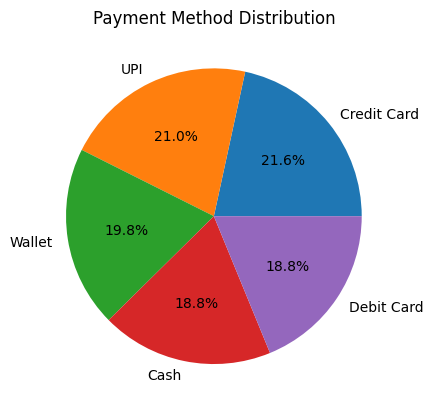

In [8]:
#payment method pie chart

plt.pie(payment_method_count, labels=payment_method_count.index,autopct="%0.1f%%")
plt.title('Payment Method Distribution')
plt.show()

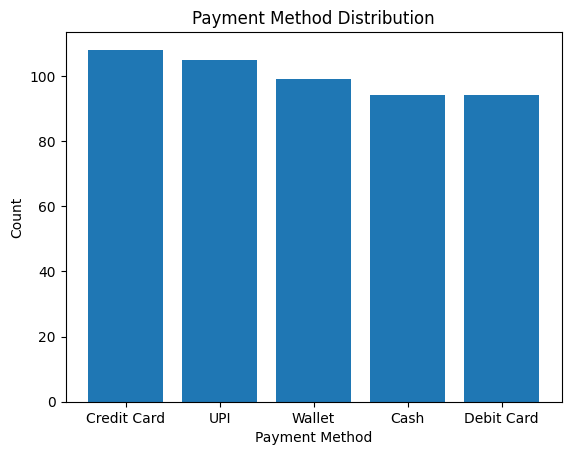

In [9]:
#payment method bar chart

plt.bar(payment_method_count.index, payment_method_count.values)
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

In [32]:
#date count insights
Date_count = df['Order_Date'].value_counts().index
print(Date_count)

Index(['09-04-2025', '24-12-2024', '25-03-2025', '05-04-2025', '22-01-2025',
       '22-12-2024', '22-03-2025', '28-12-2024', '04-05-2025', '09-12-2024',
       ...
       '14-03-2025', '04-12-2024', '04-04-2025', '22-02-2025', '11-12-2024',
       '19-04-2025', '26-01-2025', '06-04-2025', '09-01-2025', '04-02-2025'],
      dtype='object', name='Order_Date', length=167)


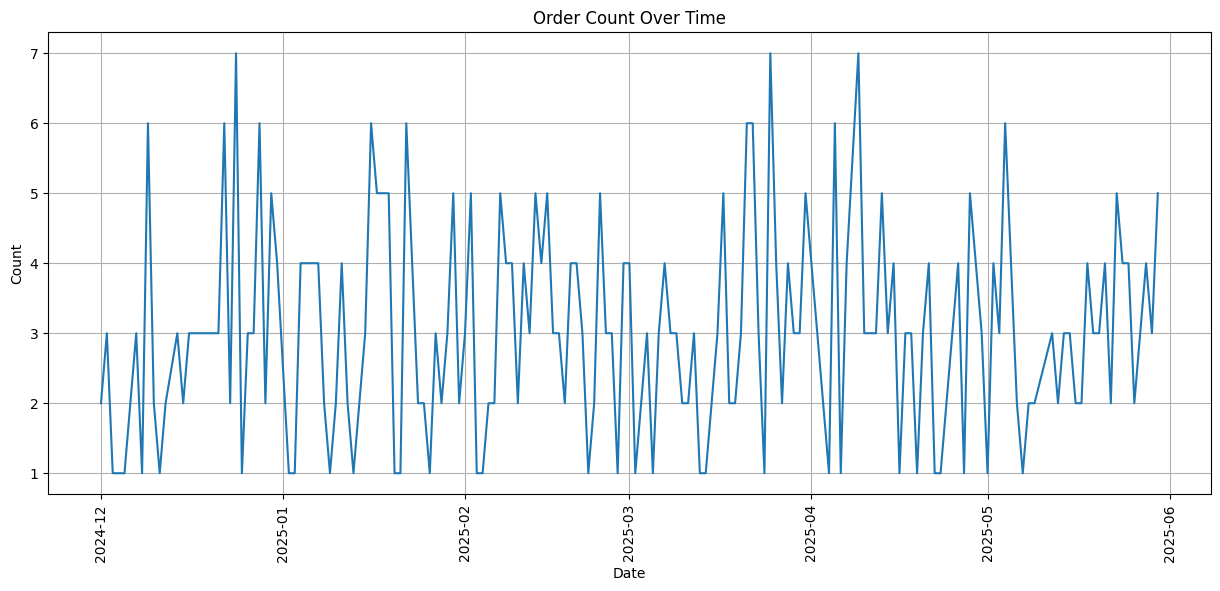

In [53]:
# Line chart of Date count
date_counts = df['Order_Date'].value_counts().sort_index()

plt.figure(figsize=(15, 6))
plt.plot(date_counts.index, date_counts.values)
plt.title('Order Count Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

In [12]:
#Days count insights

Days_count = df['Day_of_Week'].value_counts()
print(Days_count)

Day_of_Week
Saturday     77
Sunday       76
Monday       74
Tuesday      73
Friday       70
Wednesday    69
Thursday     61
Name: count, dtype: int64


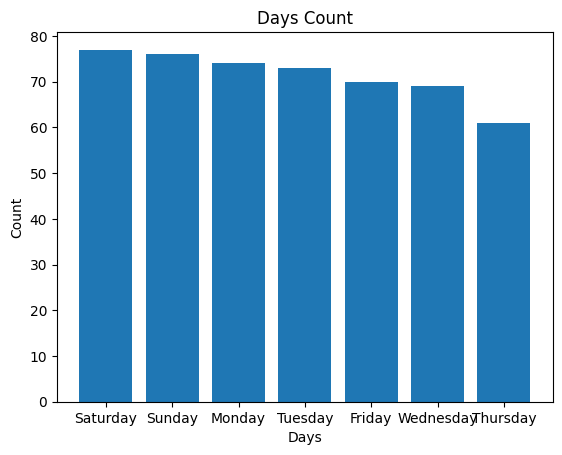

In [13]:
#Days count bar chart

plt.bar(Days_count.index, Days_count.values)

plt.title('Days Count')
plt.xlabel('Days')
plt.ylabel('Count')
plt.show()

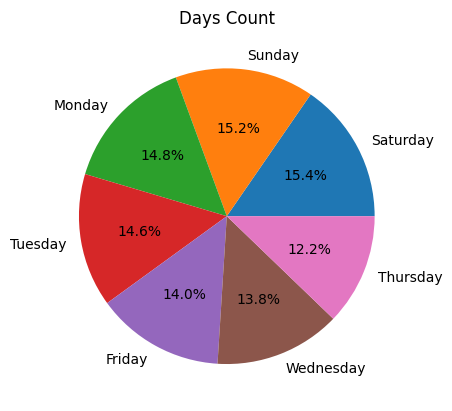

In [14]:
#Days count pie chart

plt.pie(Days_count, labels=Days_count.index,autopct="%0.1f%%")
plt.title('Days Count')
plt.show()

In [15]:
#categories count

Categories_count = df['Category'].value_counts()
print(Categories_count)

Category
Fast Food       109
South Indian    109
Rice Dishes      99
Curry            83
Chinese          53
North Indian     37
Italian          10
Name: count, dtype: int64


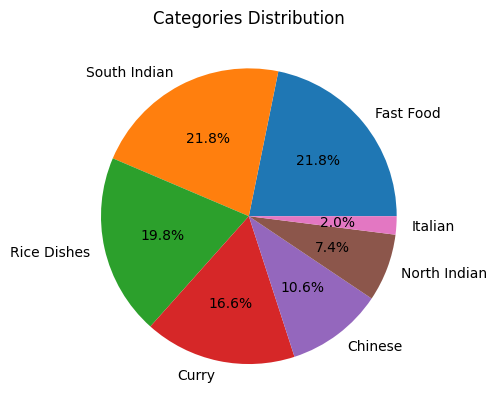

In [16]:
#categories pi chart

plt.pie(Categories_count, labels=Categories_count.index,autopct="%0.1f%%")
plt.title('Categories Distribution')
plt.show()

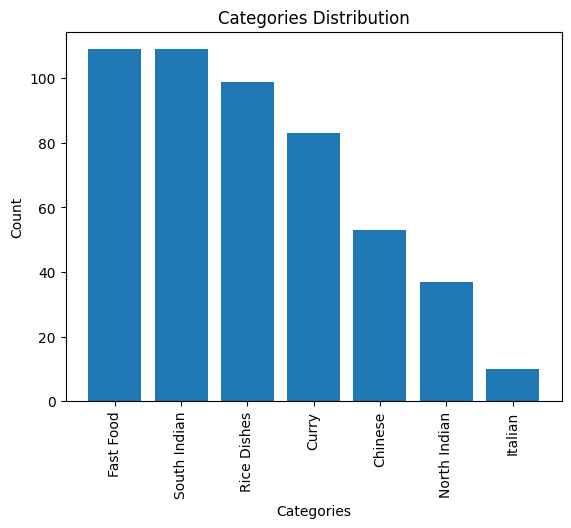

In [17]:
#categories bar chart

plt.bar(Categories_count.index, Categories_count.values)

plt.title('Categories Distribution')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [18]:
#Food items count

Food_items_count = df['Food_Item'].value_counts()
print(Food_items_count)

Food_Item
Biryani                 64
Chicken Curry           54
Dosa                    47
Burger                  44
Pizza                   38
Fried Rice              35
Idli Sambar             32
Noodles                 31
Parotta                 30
Paneer Butter Masala    29
Shawarma                27
Manchurian              22
Chole Bhature           19
Dal Tadka               18
Pasta                   10
Name: count, dtype: int64


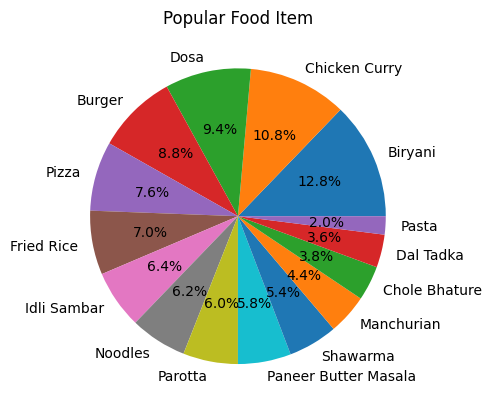

In [19]:
plt.pie(Food_items_count, labels=Food_items_count.index,autopct="%0.1f%%")
plt.title('Popular Food Item')
plt.show()

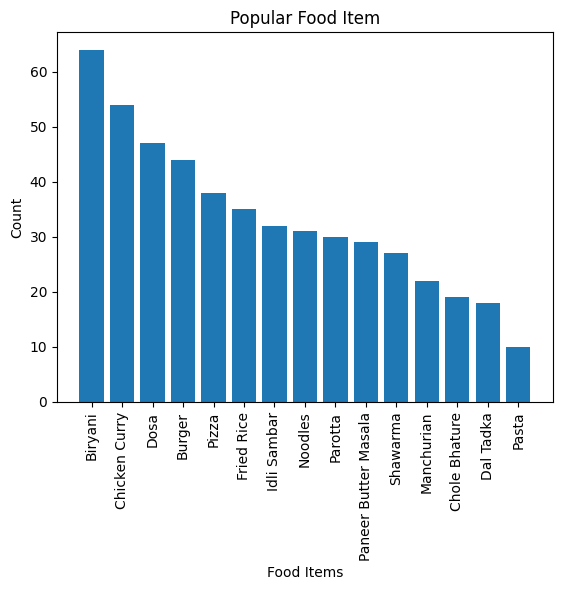

In [20]:
plt.bar(Food_items_count.index,Food_items_count.values)
plt.title('Popular Food Item')
plt.xlabel('Food Items')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [21]:
#food item quantity wise

food_item_quantity = df.groupby('Food_Item')['Quantity'].sum()
print(food_item_quantity)

Food_Item
Biryani                 108
Burger                   85
Chicken Curry            97
Chole Bhature            31
Dal Tadka                31
Dosa                     77
Fried Rice               63
Idli Sambar              59
Manchurian               41
Noodles                  52
Paneer Butter Masala     49
Parotta                  50
Pasta                    16
Pizza                    61
Shawarma                 55
Name: Quantity, dtype: int64


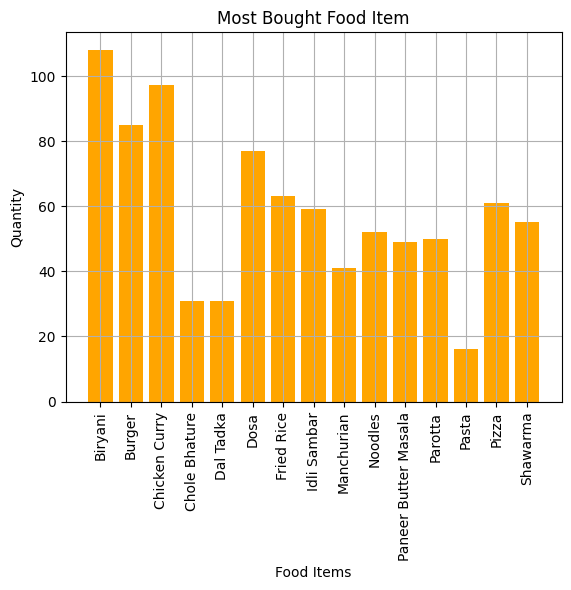

In [22]:
#most bought food item in bar chart

plt.bar(food_item_quantity.index,food_item_quantity.values,color = "Orange")
plt.title('Most Bought Food Item')
plt.xlabel('Food Items')
plt.ylabel('Quantity')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

In [23]:
#Location count

location_count = df['Location'].value_counts()
print(location_count)

Location
Velachery       61
Mylapore        56
Porur           55
Tambaram        51
T. Nagar        49
Anna Nagar      47
Adyar           46
Chromepet       46
Kodambakkam     45
Nungambakkam    44
Name: count, dtype: int64


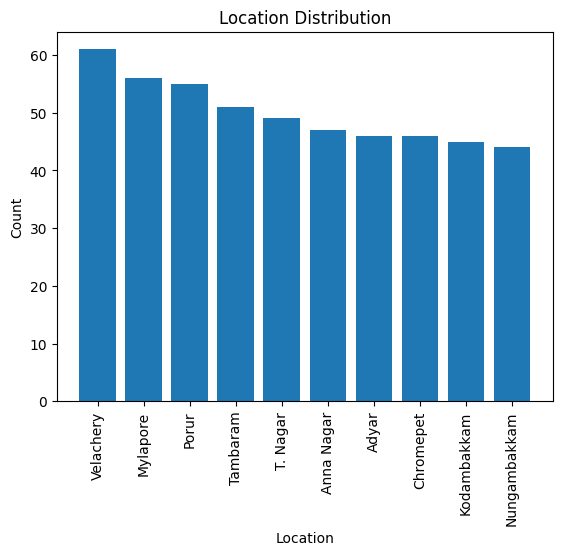

In [34]:
#location

plt.bar(location_count.index, location_count.values)

plt.title('Location Distribution')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [35]:
#category wise food items using groupby method

category_food_items = df.groupby('Category')['Food_Item'].value_counts()
print(category_food_items)

Category      Food_Item           
Chinese       Noodles                 31
              Manchurian              22
Curry         Chicken Curry           54
              Paneer Butter Masala    29
Fast Food     Burger                  44
              Pizza                   38
              Shawarma                27
Italian       Pasta                   10
North Indian  Chole Bhature           19
              Dal Tadka               18
Rice Dishes   Biryani                 64
              Fried Rice              35
South Indian  Dosa                    47
              Idli Sambar             32
              Parotta                 30
Name: count, dtype: int64


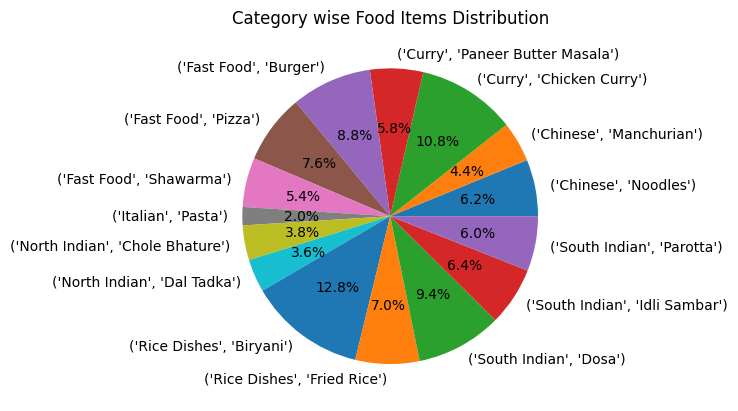

In [36]:
plt.pie(category_food_items, labels=category_food_items.index,autopct="%0.1f%%")
plt.title('Category wise Food Items Distribution')
plt.show()

In [37]:
#unit price

max_unitprice = df['Unit_Price'].max()
min_unitprice = df['Unit_Price'].min()
avg_unitprice = df['Unit_Price'].mean()

print(max_unitprice)
print(min_unitprice)
print(avg_unitprice)

270
40
135.89


In [38]:
#max & min price items

max_costitem = df[df['Unit_Price']==max_unitprice]['Food_Item'].unique()
min_costitem = df[df['Unit_Price']==min_unitprice]['Food_Item'].unique()

print(max_costitem)
print(min_costitem)

['Pizza']
['Idli Sambar']


In [39]:
#delivery fee

free_delivery_area = df[df['Delivery_Fee']==0]['Location'].value_counts()
print("Free delivery count area wise:\n",free_delivery_area)

max_delfee = df['Delivery_Fee'].max()
min_delfee = df['Delivery_Fee'].min()
avg_delfee = df['Delivery_Fee'].mean()

print("\nMaximum delivery Fee:",max_delfee)
print("Minimum delivery Fee:",min_delfee)
print("Average delivery Fee:",avg_delfee)

Free delivery count area wise:
 Location
Adyar           18
Mylapore        15
Nungambakkam    12
Chromepet       12
Tambaram        12
Velachery       12
T. Nagar        11
Anna Nagar      11
Kodambakkam      9
Porur            8
Name: count, dtype: int64

Maximum delivery Fee: 40
Minimum delivery Fee: 0
Average delivery Fee: 22.06


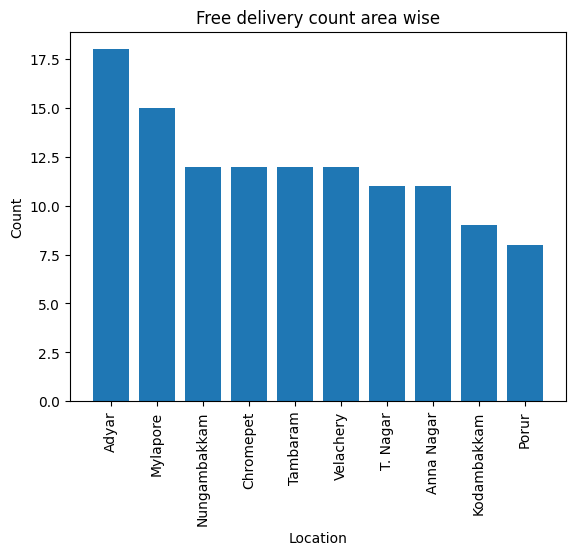

In [41]:
plt.bar(free_delivery_area.index, free_delivery_area.values)
plt.title('Free delivery count area wise')
plt.xlabel('Location')
plt.ylabel('Count')

plt.xticks(rotation=90)
plt.show()

In [42]:
#customer insights

customer = df['Customer_ID'].value_counts()
print(customer)

Customer_ID
CUST167    9
CUST185    8
CUST172    7
CUST109    7
CUST054    7
          ..
CUST134    1
CUST158    1
CUST004    1
CUST022    1
CUST128    1
Name: count, Length: 176, dtype: int64


In [43]:
#Total amount

max_total_amount = df['Total_Amount'].max()
min_total_amount = df['Total_Amount'].min()


print(max_total_amount)
print(min_total_amount)


1044
40


In [44]:
#High purchae customer

high_purchase_customer = df[df['Total_Amount']==max_total_amount]['Customer_ID'].unique()
print(high_purchase_customer)

low_purchase_customer = df[df['Total_Amount']==min_total_amount]['Customer_ID'].unique()
print(low_purchase_customer)

['CUST162']
['CUST071' 'CUST066']


In [45]:
#Totalrevenue

total_revenue = df['Grand_Total'].sum()
print(total_revenue,"₹")

129233 ₹


Order counts by year:
Year
2025    419
2024     81
Name: count, dtype: int64


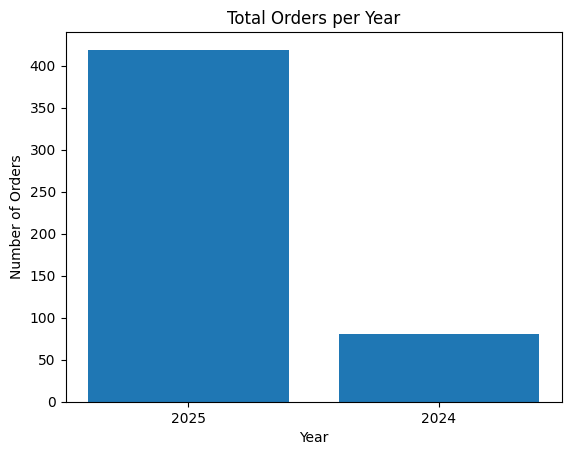

In [47]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')
df['Year'] = df['Order_Date'].dt.year
yearly_counts = df['Year'].value_counts()

print("Order counts by year:")
print(yearly_counts)


plt.bar(yearly_counts.index.astype(str), yearly_counts.values)
plt.title('Total Orders per Year')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.show()

Monthly Order Counts:
Order_Date
March       92
February    88
April       82
May         82
December    81
January     75
Name: count, dtype: int64


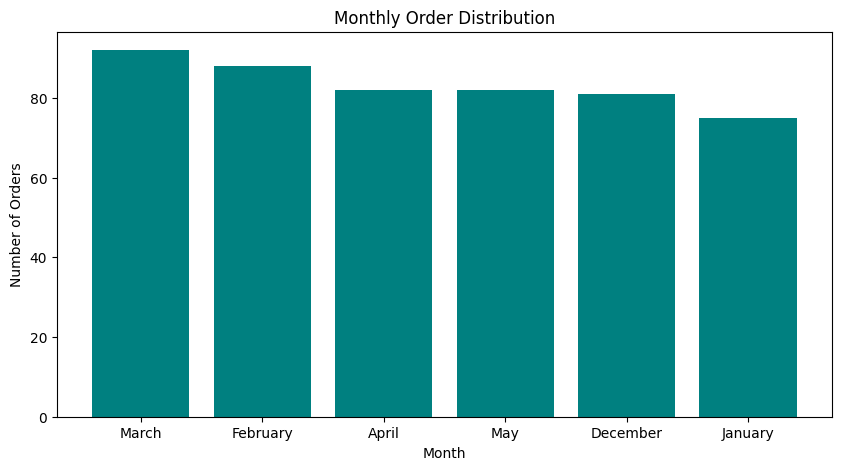

In [48]:
# Counting orders by month
monthly_counts = df['Order_Date'].dt.month_name().value_counts()

print("Monthly Order Counts:")
print(monthly_counts)

# Visualization
plt.figure(figsize=(10, 5))
plt.bar(monthly_counts.index, monthly_counts.values, color='teal')
plt.title('Monthly Order Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()

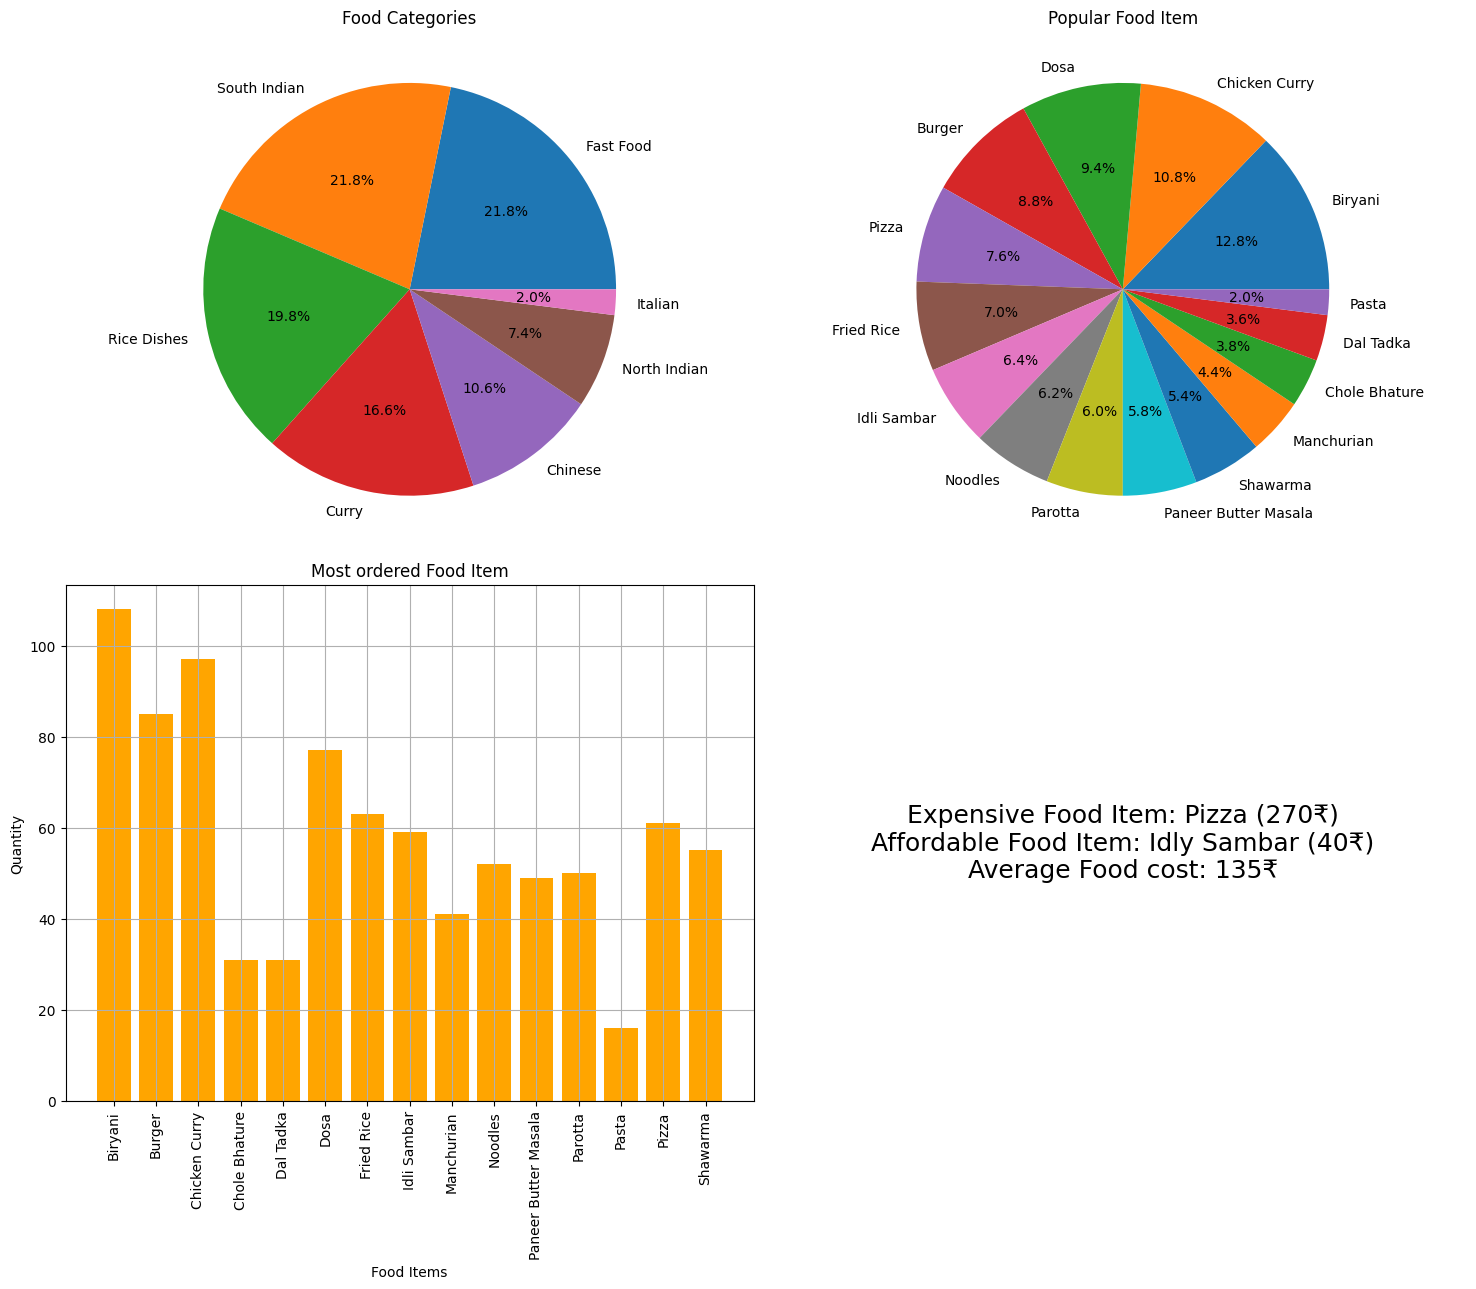

In [49]:
#Dashboard-1 : Food related

plt.figure(figsize=(15 ,13))

plt.subplot(2, 2, 1)
#categories pi chart
plt.pie(Categories_count, labels=Categories_count.index,autopct="%0.1f%%")
plt.title('Food Categories')


plt.subplot(2,2,2)
#popular food item
plt.pie(Food_items_count, labels=Food_items_count.index,autopct="%0.1f%%")
plt.title('Popular Food Item')


plt.subplot(2,2,3)
#most buyed food item in bar chart
plt.bar(food_item_quantity.index,food_item_quantity.values,color = "Orange")
plt.title('Most ordered Food Item')
plt.xlabel('Food Items')
plt.ylabel('Quantity')
plt.xticks(rotation=90)
plt.grid(True)

plt.subplot(2,2,4)
#Food data


plt.axis('off')

plt.text(0.5, 0.5, """Expensive Food Item: Pizza (270₹)
Affordable Food Item: Idly Sambar (40₹)
Average Food cost: 135₹""",ha='center',va='center',fontsize=18)


#display
plt.tight_layout()
plt.show()

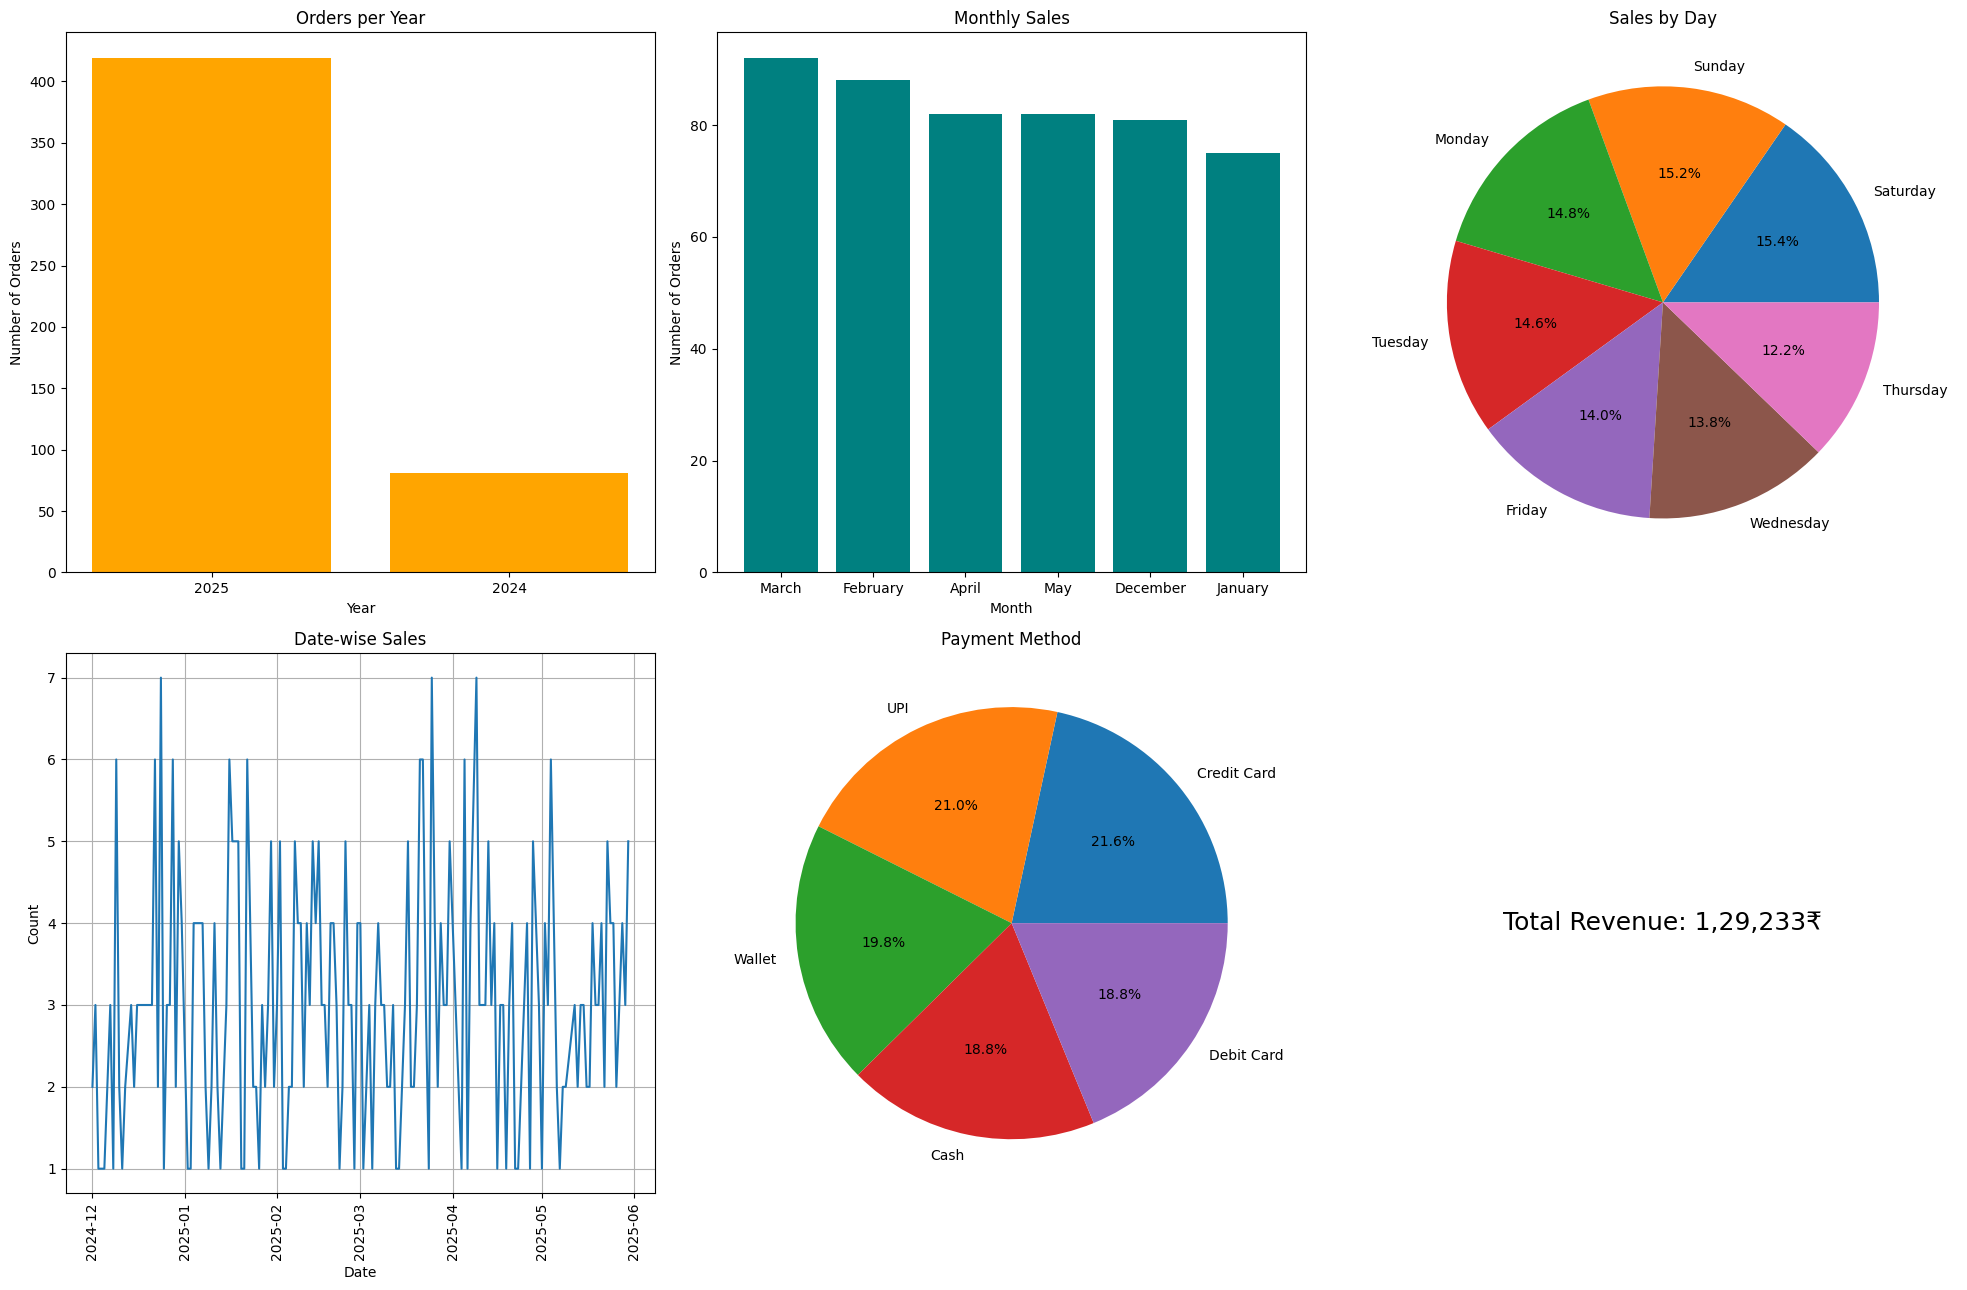

In [54]:
#Dashboard-2 : sales analysis

plt.figure(figsize=(20 ,13))


plt.subplot(2, 3, 1)
#yearly sales
plt.bar(yearly_counts.index.astype(str), yearly_counts.values,color="Orange")
plt.title('Orders per Year')
plt.xlabel('Year')
plt.ylabel('Number of Orders')


plt.subplot(2, 3, 2)
#monthly sales
plt.bar(monthly_counts.index, monthly_counts.values, color='teal')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Number of Orders')


plt.subplot(2, 3, 3)
#days sales
plt.pie(Days_count, labels=Days_count.index,autopct="%0.1f%%")
plt.title('Sales by Day')

plt.subplot(2, 3, 4)
#date sales
plt.plot(date_counts.index, date_counts.values)
plt.title('Date-wise Sales')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.grid(True)

plt.subplot(2, 3, 5)
#payment method
plt.pie(payment_method_count, labels=payment_method_count.index,autopct="%0.1f%%")
plt.title('Payment Method')

plt.subplot(2, 3, 6)
#Data: revenue
plt.axis('off')
plt.text(0.5,0.5,"Total Revenue: 1,29,233₹",ha='center',va='center',fontsize=18)


#display
plt.tight_layout()
plt.show()

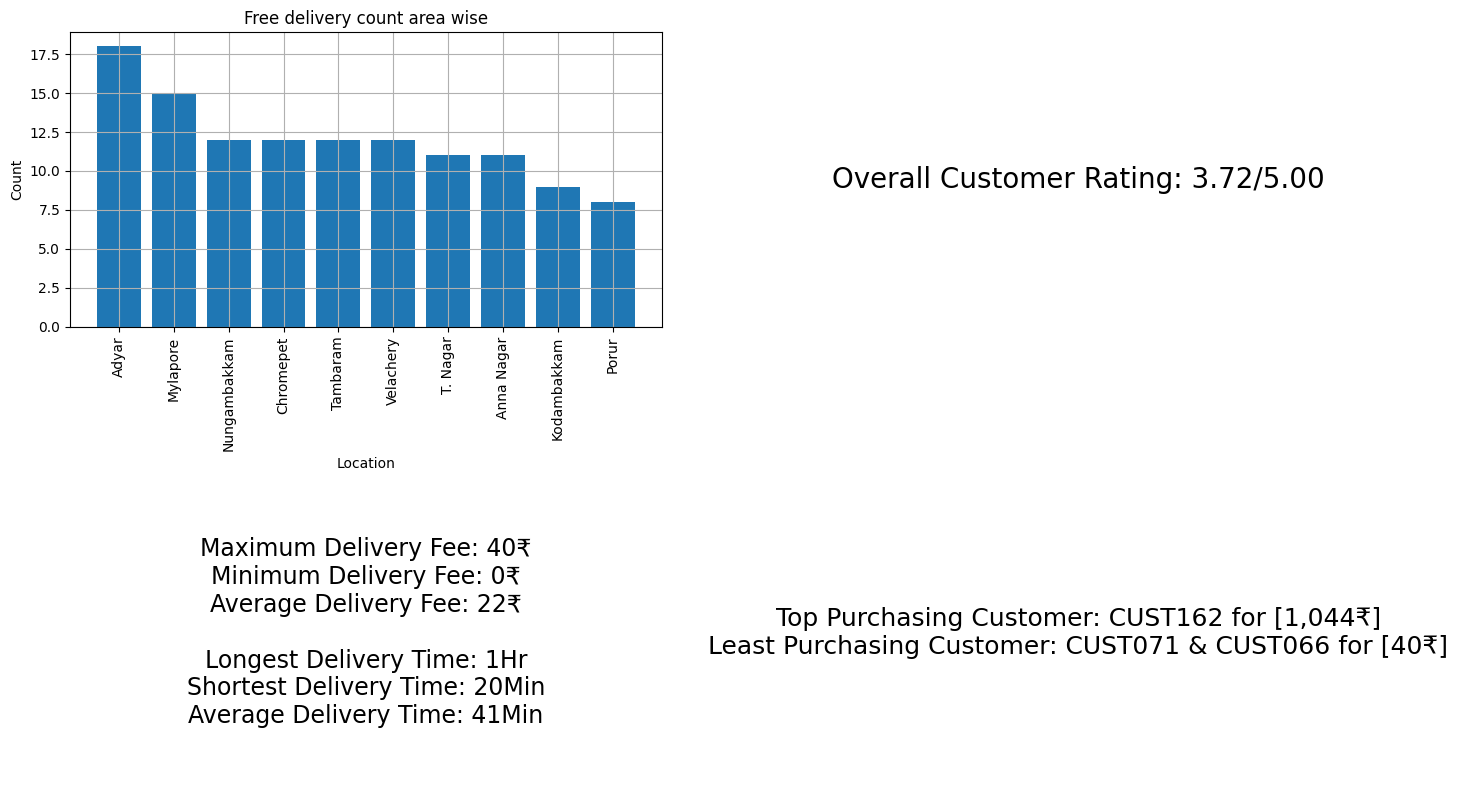

In [60]:
#Dashboard-3 : Customer side insights

plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
#Free delivery area
plt.bar(free_delivery_area.index, free_delivery_area.values)
plt.title('Free delivery count area wise')
plt.xlabel('Location')
plt.ylabel('Count')
plt.grid(True)
plt.xticks(rotation=90)


plt.subplot(2,2,2)
# customer data
plt.axis('off')
plt.text(0.5,0.5,"Overall Customer Rating: 3.72/5.00",ha='center',va='center',fontsize=20)


plt.subplot(2,2,3)
#delivery data
plt.axis('off')
plt.text(0.5,0.5,"""Maximum Delivery Fee: 40₹
Minimum Delivery Fee: 0₹
Average Delivery Fee: 22₹

Longest Delivery Time: 1Hr
Shortest Delivery Time: 20Min
Average Delivery Time: 41Min""",ha='center',va='center',fontsize=17)


plt.subplot(2,2,4)
#customer Data
plt.axis('off')
plt.text(0.5,0.5,"""Top Purchasing Customer: CUST162 for [1,044₹]
Least Purchasing Customer: CUST071 & CUST066 for [40₹]""",ha='center',va='center',fontsize=18)


#display
plt.tight_layout()
plt.show()


Now that we have the order counts by time period, we can visualize this distribution.

1. payment method - pie chart                     @@@
2. Day of week - Bar chart                        @@@
3. Location - Bar chart                           @@@
4. Day - Bar chart                                @@@
5. Date - line chart                               *
6. Food Categories - Bar chart                    @@@
7. Food items - Bar chart                         @@@
8. Food categories items - pie chart               *
9. location - Bar chart                           @@@
10. Time (seperate as 6) - ? chart                 *
11. customer rating - Mean value assigning        @@@
12. Delivery time - Mean value assign             @@@
13. Free delivery area finding                     *
14. area wise food trends                          *
15. quantity wise food order analysis              *
16. delivery-order, Grand-total, Total amount      *
17. maximum & minimum delivery time & Mean         @@@
18. Rating Nan count Mean value                    @@@
19. Food- unit price                               *

**done**
1. date
2. time (function use pannanum**)


---



**Completed**
1. Day
2. Location
3. Food items(popular,most buyed)
4. category(normal,items wise)
5. Quantity used in food item(most buyed food itmes)
6. Cost item(max,min,mean,and its name)
7. Delivery fee(free delivery area,max and min)
8. Customer id (order count)
9. Grand total(total revenue)
10. total amount(max & min and the customer name)
11. Payment method
12. Delivery time
13. Customer rating

